# 🚲 Visualising London Bike Hires

An exploratory data analysis of Transport for London (TfL) bike-hire data.

This notebook walks through the full workflow:

1. **Setup** — import libraries and set the plotting style
2. **Load & prepare the data** — parse dates, derive calendar and season features
3. **Explore** — inspect structure and summary statistics
4. **Visualise** — time series, distributions, boxplots, violin plots, and weather correlations

> **Data:** the notebook expects `data/london_bikes.csv` relative to this notebook.

---

## 1. Setup

Import the libraries used throughout the analysis and configure a clean,
consistent plotting style.

In [ ]:
# Data handling
import pandas as pd          # DataFrames: Excel-like tables in Python
import numpy as np           # Fast numerical operations on arrays

# Visualisation
import seaborn as sns                        # High-level statistical charts
import matplotlib.pyplot as plt              # Underlying plotting engine
import matplotlib.dates as mdates            # Date formatting on axes
from matplotlib.ticker import FuncFormatter  # Custom tick labels (e.g. thousands separators)

# Utilities
from datetime import datetime
from skimpy import skim      # Rich summary statistics for DataFrames

import warnings
warnings.filterwarnings('ignore')  # Keep output clean

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

!pip install skimpy

In [2]:
# A clean, professional default style for every chart in the notebook
sns.set_theme(style="whitegrid")   # Subtle grid background
sns.set_palette("husl")            # Consistent, distinct colours across charts

## 2. Load the data

Read the CSV into a DataFrame and take a first look with `skim`, which reports
column types, missing values, and distributions at a glance.

In [ ]:
from pathlib import Path

RAW = "https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data"
local = Path("../data/london_bikes.csv")

bikes = pd.read_csv(local if local.exists() else f"{RAW}/london_bikes.csv")
skim(bike)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 5634   │ │ float64     │ 22    │                                                          │
│ │ Number of columns │ 40     │ │ string      │ 11    │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 6     │                                                          │
│                                │ bool        │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA   ┃ NA %           ┃ mean    ┃ sd     ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ bikes_hired    │    0 │              0 │   26230 │   9335 │     0 │ 19860 │ 26060 │ 32330 │ 73090 │  ▁▇█▃  │  │
│ │ tempmax        │    0 │              0 │   14.84 │  6.405 │  -2.6 │  10.1 │  14.6 │  19.6 │  36.1 │ ▁▅█▇▂  │  │
│ │ tempmin        │    0 │              0 │   7.928 │  5.064 │ -11.1 │   4.1 │   8.1 │  11.7 │  22.1 │  ▁▆█▆▁ │  │
│ │ temp           │    0 │              0 │   11.33 │  5.511 │  -5.9 │   7.3 │  11.2 │  15.6 │  28.3 │  ▃█▇▄  │  │
│ │ feelslikemax   │    0 │              0 │   14.22 │  7.262 │  -7.2 │  10.1 │  14.6 │  19.6 │  38.2 │ ▁▄▇█▂  │  │
│ │ feelslikemin   │    0 │              0 │   6.312 │  6.386 │ -14.6 │   1.2 │   6.1 │  11.7 │  22.1 │  ▂▇▆█▁ │  │
│ │ feelslike      │    0 │              0 │   10.22 │  6.678 │  -9.1 │     5 │  10.8 │  15.6 │  28.9 │ ▁▄▇█▅  │  │
│ │ dew            │    0 │              0 │   7.426 │  4.668 │    -8 │ 4.025 │   7.6 │    11 │    19 │  ▂▆█▇▁ │  │
│ │ humidity       │    0 │              0 │   78.88 │  10.55 │  39.6 │  71.6 │  79.9 │    87 │  99.9 │  ▁▄▇█▄ │  │
│ │ precip         │    0 │              0 │    1.59 │  4.632 │     0 │     0 │ 0.165 │ 1.217 │ 168.2 │   █    │  │
│ │ precipprob     │    0 │              0 │   71.39 │   45.2 │     0 │     0 │   100 │   100 │   100 │ ▃    █ │  │
│ │ precipcover    │    0 │              0 │   9.064 │  12.01 │     0 │     0 │  8.33 │  12.5 │   100 │   █▁   │  │
│ │ snow           │    0 │              0 │ 0.01534 │ 0.2427 │     0 │     0 │     0 │     0 │   8.4 │   █    │  │
│ │ snowdepth      │    0 │              0 │ 0.04464 │  0.532 │     0 │     0 │     0 │     0 │  18.1 │   █    │  │
│ │ windgust       │ 1126 │ 19.98580049698 │   41.51 │  14.74 │   8.5 │  30.2 │    40 │  51.5 │ 120.9 │  ▃█▆▁  │  │
│ │                │      │           2606 │         │        │       │       │       │       │       │        │  │
│ │ windspeed      │    0 │              0 │   22.82 │  8.343 │   5.1 │  16.8 │  21.7 │  27.4 │  72.2 │  ▃█▃▁  │  │
│ │ winddir        │    0 │              0 │   195.8 │  92.43 │   0.1 │ 124.7 │ 220.7 │ 258.1 │ 359.8 │ ▄▃▃█▇▃ │  │
│ │ sealevelpressu │    0 │              0 │    1015 │  10.49 │ 966.6 │  1009 │  1016 │  1022 │  1048 │   ▃█▄  │  │
│ │ re             │      │                │         │        │       │       │       │       │       │        │  │
│ │ cloudcover     │    0 │              0 │   58.58 │  

## 3. Prepare the data

The raw file needs a few derived columns before it's easy to analyse:

- a proper **datetime** `date` column
- **calendar features**: month number, month name, ordered day-of-week
- a **season** label
- a **weekend / weekday** flag

### 3.1 Parse dates and extract calendar features

In [22]:
# Convert 'date' from text to real datetimes so pandas understands them
bike['date'] = pd.to_datetime(bike['date'])

# Month number (1-12) and 3-letter month name (Jan, Feb, ...)
bike['month'] = bike['date'].dt.month
bike['month_name'] = bike['date'].dt.strftime('%b')

In [23]:
# Order weekdays Mon -> Sun instead of alphabetically.
# A Categorical with `ordered=True` tells pandas the values have a natural order.
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
bike['day_of_week'] = pd.Categorical(bike['wday'], categories=day_order, ordered=True)

# Order months in calendar order rather than alphabetically
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bike['month_name'] = pd.Categorical(bike['month_name'], categories=month_order, ordered=True)

### 3.2 Derive the season

Map each month to its meteorological season and keep the seasons in a natural order.

In [24]:
def get_season(month_name):
    """Return the season for a 3-letter month abbreviation."""
    if month_name in ['Dec', 'Jan', 'Feb']:
        return 'Winter'
    elif month_name in ['Mar', 'Apr', 'May']:
        return 'Spring'
    elif month_name in ['Jun', 'Jul', 'Aug']:
        return 'Summer'
    else:  # Sep, Oct, Nov
        return 'Autumn'

bike['season_name'] = bike['month_name'].apply(get_season)

# Keep seasons in a logical order for plotting and grouping
bike['season_name'] = pd.Categorical(
    bike['season_name'],
    categories=['Winter', 'Spring', 'Summer', 'Autumn'],
    ordered=True
)

### 3.3 Flag weekends

Label Saturdays and Sundays as *Weekend*, everything else as *Weekday*.
`np.where` is a fast, vectorised way to do this across the whole column.

In [25]:
bike['weekend'] = np.where(bike['wday'].isin(['Sat', 'Sun']), 'Weekend', 'Weekday')

## 4. Explore the data

A quick look at structure and the first few rows.

In [8]:
bike.info()   # Column names, dtypes, non-null counts, memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5846 entries, 0 to 5845
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   date              5846 non-null   datetime64[ns, UTC]
 1   bikes_hired       5846 non-null   int64              
 2   tempmax           5846 non-null   float64            
 3   tempmin           5846 non-null   float64            
 4   temp              5846 non-null   float64            
 5   feelslikemax      5846 non-null   float64            
 6   feelslikemin      5846 non-null   float64            
 7   feelslike         5846 non-null   float64            
 8   dew               5846 non-null   float64            
 9   humidity          5846 non-null   float64            
 10  precip            5846 non-null   float64            
 11  precipprob        5846 non-null   int64              
 12  precipcover       5846 non-null   float64            
 13  pre

In [9]:
bike.head()   # First 5 rows

,date,bikes_hired,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,description,icon,month_name,month,day_of_week,wday,week,year,weekend,season_name
0,2010-07-30 00:00:00+00:00,6897,21.5,10.7,16.8,21.5,10.7,16.8,10.3,68.1,...,Partly cloudy throughout the day.,partly-cloudy-day,Jul,7,Fri,Fri,30,2010,Weekday,Summer
1,2010-07-31 00:00:00+00:00,5564,23.0,15.0,18.9,23.0,15.0,18.9,14.3,76.3,...,Partly cloudy throughout the day with rain.,rain,Jul,7,Sat,Sat,30,2010,Weekend,Summer
2,2010-08-01 00:00:00+00:00,4303,21.0,14.0,17.4,21.0,14.0,17.4,11.5,69.1,...,Partly cloudy throughout the day.,partly-cloudy-day,Aug,8,Sun,Sun,30,2010,Weekend,Summer
3,2010-08-02 00:00:00+00:00,6642,20.4,14.3,17.1,20.4,14.3,17.1,11.6,71.1,...,Partly cloudy throughout the day with rain.,rain,Aug,8,Mon,Mon,31,2010,Weekday,Summer
4,2010-08-03 00:00:00+00:00,7966,21.6,11.6,17.2,21.6,11.6,17.2,11.4,71.4,...,Becoming cloudy in the afternoon with rain cle...,rain,Aug,8,Tue,Tue,31,2010,Weekday,Summer


## 5. Time series: hires over time

Scatter every daily observation from 2014 to 2024, then overlay the mean number
of bikes hired **before 2023** and **from 2023 onward** to see whether usage shifted.

In [26]:
# --- Period means -------------------------------------------------------
# The 'date' column is timezone-aware, so make these bounds tz-aware too (utc=True).
start_p1 = pd.to_datetime("2014-01-01", utc=True)
end_p1   = pd.to_datetime("2022-12-31", utc=True)
start_p2 = pd.to_datetime("2023-01-01", utc=True)
end_p2   = pd.to_datetime("2025-12-31", utc=True)

mean_2014_2022 = bike[(bike['date'] >= start_p1) & (bike['date'] <= end_p1)]['bikes_hired'].mean()
mean_2023_on   = bike[(bike['date'] >= start_p2) & (bike['date'] <= end_p2)]['bikes_hired'].mean()

# --- Data to plot (2014-2026) -------------------------------------------
bike_filtered = bike[
    (bike['date'] >= start_p1) & (bike['date'] < pd.to_datetime("2026-01-01", utc=True))
].copy()

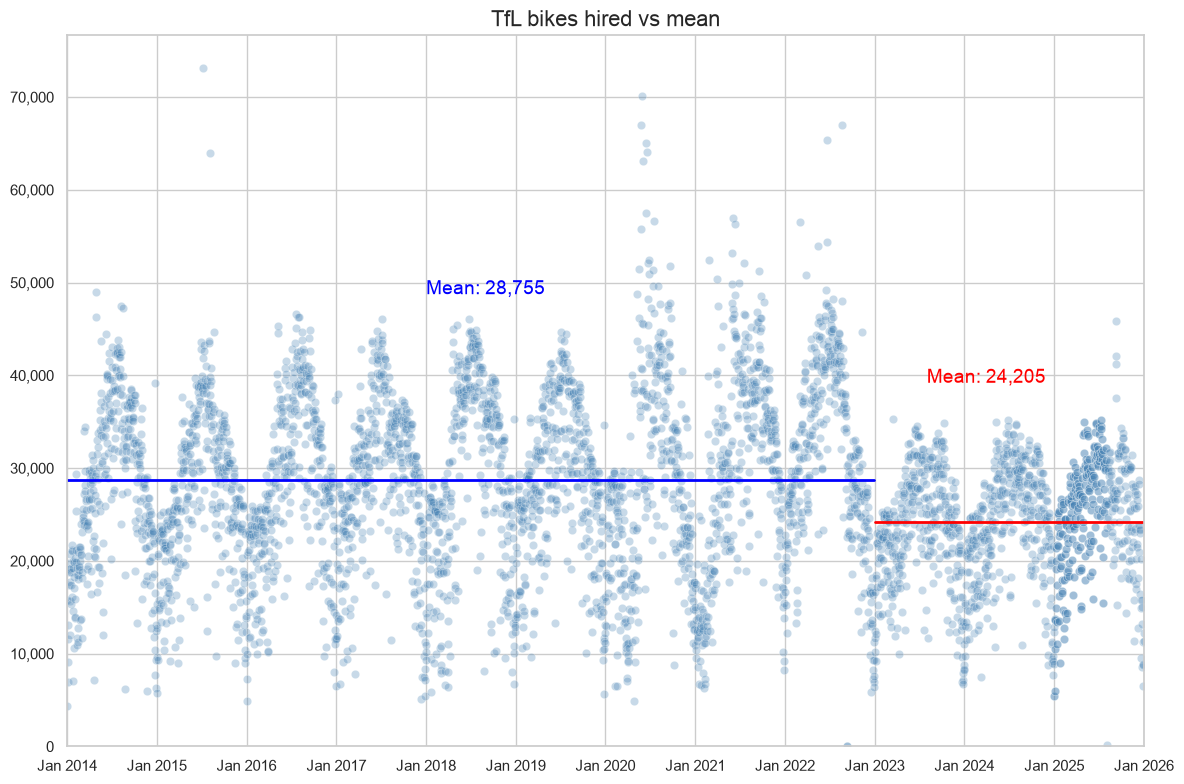

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))

# All daily observations (semi-transparent so overlap is visible)
sns.scatterplot(data=bike_filtered, x='date', y='bikes_hired',
                alpha=0.3, color='steelblue', ax=ax)
                
# Mean lines for each period
ax.plot([start_p1, end_p1], [mean_2014_2022, mean_2014_2022], color='blue', linewidth=2)
ax.plot([start_p2, end_p2], [mean_2023_on,   mean_2023_on],   color='red',  linewidth=2)

# Label the mean lines
ax.text(pd.to_datetime("2018-01-01"), mean_2014_2022 + 20000,
        f"Mean: {mean_2014_2022:,.0f}", color="blue", fontsize=14)
ax.text(pd.to_datetime("2023-08-01"), mean_2023_on + 15000,
        f"Mean: {mean_2023_on:,.0f}", color="red", fontsize=14)

# Cosmetics
ax.set_title("TfL bikes hired vs mean", fontsize=16)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.set_xlim(pd.to_datetime("2014-01-01"), pd.to_datetime("2026-01-01"))
ax.set_ylim(0)

plt.tight_layout()
plt.show()

## 6. Summary statistics

Overall statistics, then breakdowns by year, weekend/weekday, day, month, and season.

In [17]:
print("Summary statistics for bikes_hired:")
bike['bikes_hired'].describe()

Summary statistics for bikes_hired:


count     5846.00000
mean     26183.15703
std       9237.99113
min          0.00000
25%      19952.00000
50%      26056.50000
75%      32106.75000
max      73094.00000
Name: bikes_hired, dtype: float64

In [27]:
# By year
bike.groupby('year')['bikes_hired'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2010,155.00,"14,069.76","5,616.91","2,764.00","9,297.00","14,010.00","18,677.50","27,964.00"
2011,365.00,"19,568.35","5,497.47","4,555.00","16,260.00","20,264.00","23,708.00","29,417.00"
2012,366.00,"26,008.97","9,429.40","3,531.00","19,282.00","26,178.50","32,532.75","47,102.00"
2013,365.00,"22,042.35","7,276.49","3,728.00","17,555.00","22,021.00","27,371.00","35,580.00"
2014,365.00,"27,462.73","9,065.09","4,327.00","20,532.00","27,676.00","34,437.00","49,025.00"
2015,365.00,"27,046.13","8,547.89","5,779.00","22,056.00","26,618.00","32,857.00","73,094.00"
2016,366.00,"28,152.01","8,850.96","4,894.00","22,402.00","27,881.50","35,130.00","46,625.00"
2017,365.00,"28,619.30","8,376.55","5,143.00","24,064.00","29,490.00","34,459.00","46,035.00"
2018,365.00,"28,952.16","10,174.35","5,859.00","21,759.00","29,190.00","37,677.00","46,084.00"


In [28]:
# Weekend vs weekday
bike.groupby('weekend')['bikes_hired'].describe()

,count,mean,std,min,25%,50%,75%,max
weekend,,,,,,,,
Weekday,"4,024.00","27,503.49","8,452.16",188.00,"22,083.00","27,152.00","33,029.75","73,094.00"
Weekend,"1,610.00","23,042.93","10,594.74",0.00,"15,029.50","21,610.50","29,686.00","70,170.00"


In [29]:
# By day of week (ordered Mon -> Sun)
bike.groupby('day_of_week')['bikes_hired'].describe()

,count,mean,std,min,25%,50%,75%,max
day_of_week,,,,,,,,
Mon,805.00,"25,979.39","8,122.84","3,971.00","20,710.00","25,735.00","31,151.00","67,034.00"
Tue,805.00,"28,134.89","8,513.48",188.00,"22,692.00","27,878.00","33,854.00","65,326.00"
Wed,805.00,"28,313.25","8,386.90","4,327.00","22,987.00","28,059.00","33,882.00","54,360.00"
Thu,804.00,"28,252.92","8,602.55","5,649.00","22,879.50","27,671.00","33,955.00","73,094.00"
Fri,805.00,"26,837.95","8,388.26","5,402.00","21,387.00","26,508.00","32,299.00","66,972.00"
Sat,805.00,"24,054.68","10,816.48",0.00,"16,087.00","22,475.00","30,424.00","70,170.00"
Sun,805.00,"22,031.18","10,275.72",0.00,"14,242.00","20,876.00","29,311.00","63,116.00"


In [30]:
# By month (calendar order)
bike.groupby('month_name')['bikes_hired'].describe()

,count,mean,std,min,25%,50%,75%,max
month_name,,,,,,,,
Jan,465.00,"18,630.37","5,981.96","3,728.00","13,894.00","19,085.00","23,280.00","38,042.00"
Feb,424.00,"20,325.64","6,271.12","3,531.00","16,048.25","20,756.50","24,537.75","52,485.00"
Mar,465.00,"22,863.22","7,412.10","5,062.00","18,219.00","23,462.00","27,228.00","56,568.00"
Apr,450.00,"25,957.45","7,452.41","4,872.00","21,155.00","26,061.50","30,681.50","49,025.00"
May,465.00,"30,244.11","8,266.28","10,684.00","24,556.00","29,725.00","35,109.00","70,170.00"
Jun,450.00,"33,081.97","8,468.73","6,061.00","27,587.25","32,417.00","38,841.75","65,326.00"
Jul,467.00,"34,308.74","8,271.86","5,564.00","28,470.50","34,776.00","41,000.00","73,094.00"
Aug,496.00,"31,033.92","9,487.31",188.00,"25,526.00","31,690.50","38,121.25","66,972.00"
Sep,480.00,"30,271.70","8,034.76",0.00,"24,888.25","30,992.50","36,008.75","51,764.00"


In [31]:
# By season
bike.groupby('season_name')['bikes_hired'].describe()

,count,mean,std,min,25%,50%,75%,max
season_name,,,,,,,,
Winter,"1,385.00","18,612.84","6,529.98","2,764.00","13,720.00","18,866.00","23,519.00","52,485.00"
Spring,"1,380.00","26,359.25","8,296.02","4,872.00","21,022.25","26,179.00","31,200.75","70,170.00"
Summer,"1,413.00","32,768.50","8,877.76",188.00,"27,297.00","33,084.00","39,282.00","73,094.00"
Autumn,"1,456.00","27,003.26","7,598.86",0.00,"21,912.00","27,201.00","32,369.50","51,764.00"


## 7. Distributions

How are daily hire counts distributed? Histograms and density (KDE) plots,
overall and split by season and month.

### 7.1 Overall histogram

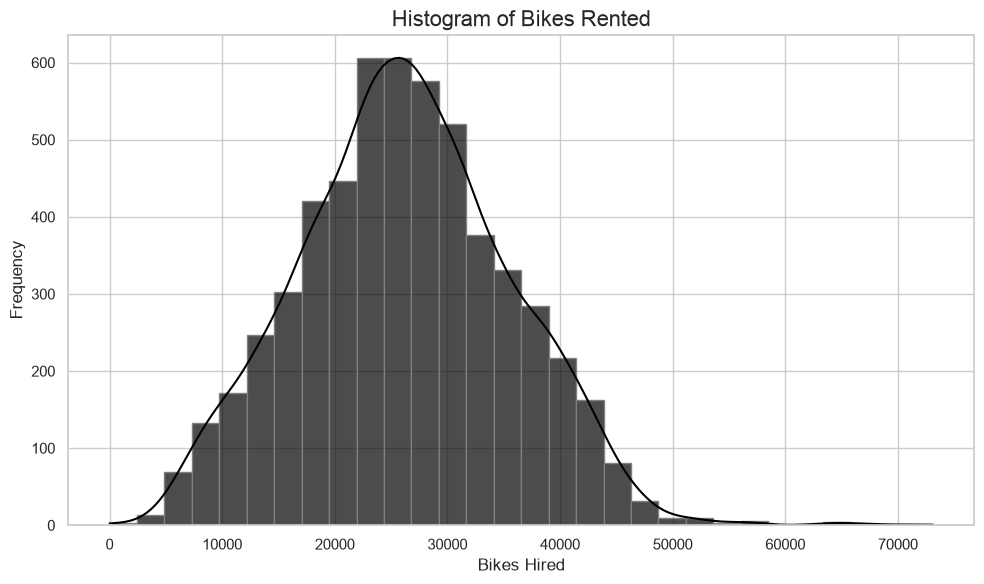

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=bike, x='bikes_hired',
    bins=30, alpha=0.7,
    color='black', edgecolor='grey',
    kde=True            # Overlay a smooth density curve
)
plt.title('Histogram of Bikes Rented', fontsize=16)
plt.xlabel('Bikes Hired', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### 7.2 Histograms by season

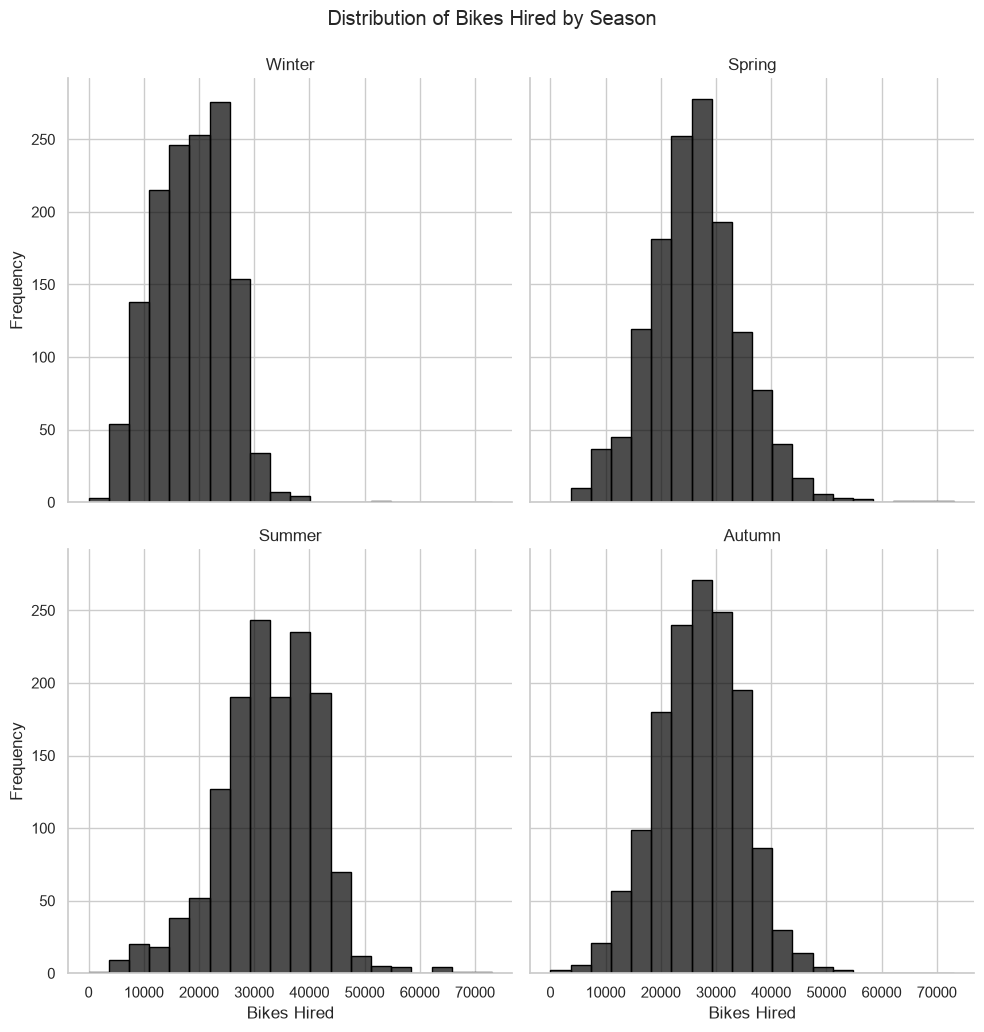

In [33]:
g = sns.displot(
    data=bike, x='bikes_hired',
    col='season_name', col_wrap=2,
    kind='hist', bins=20,
    color='black', edgecolor='black', alpha=0.7
)
g.set_axis_labels('Bikes Hired', 'Frequency')
g.set_titles('{col_name}')
g.fig.suptitle('Distribution of Bikes Hired by Season', y=1.03)
plt.show()

### 7.3 Histograms by month

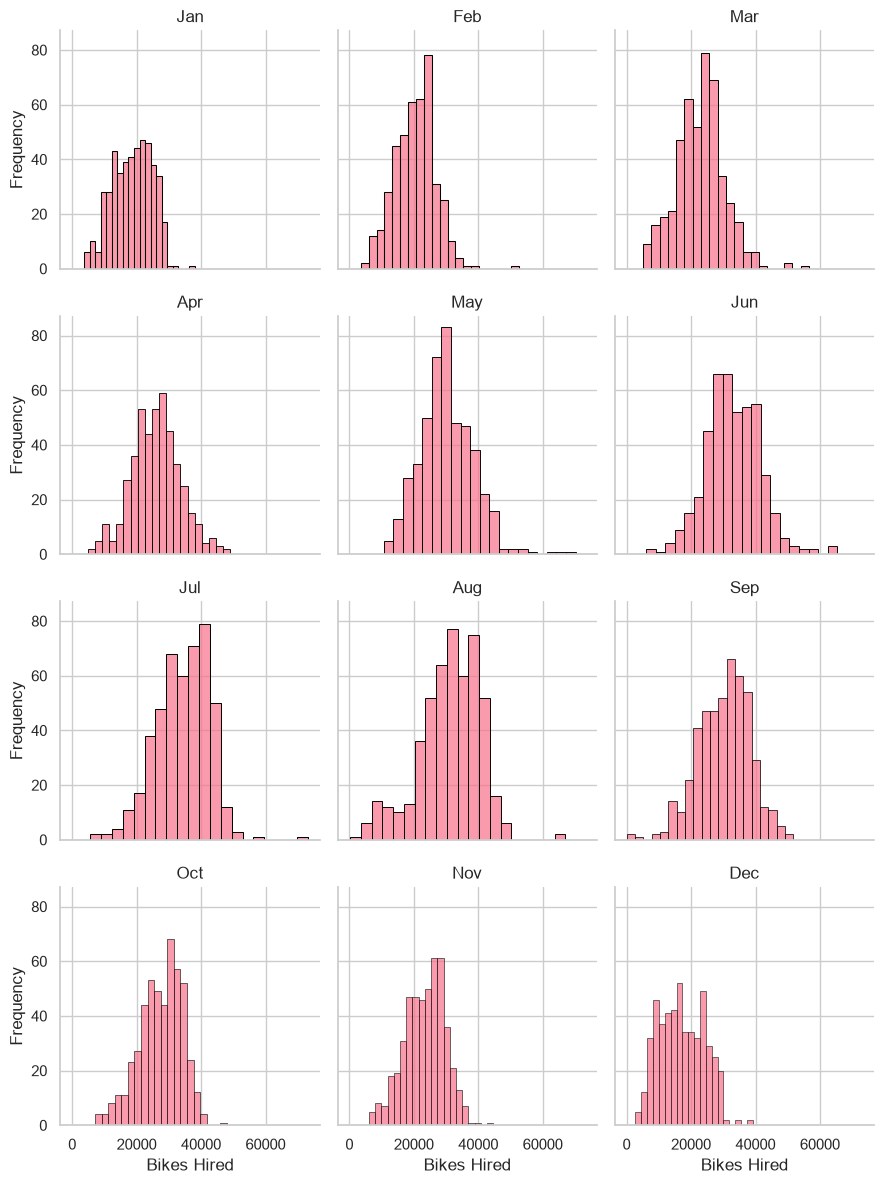

In [34]:
g = sns.FacetGrid(bike, col='month_name', col_wrap=3)
g.map(sns.histplot, 'bikes_hired', bins=20, alpha=0.7, edgecolor='black')
g.set_titles("{col_name}")
g.set_axis_labels('Bikes Hired', 'Frequency')
plt.tight_layout()
plt.show()

### 7.4 Density plots

Density plots are smoothed histograms — the y-axis is probability per unit
rather than a raw count.

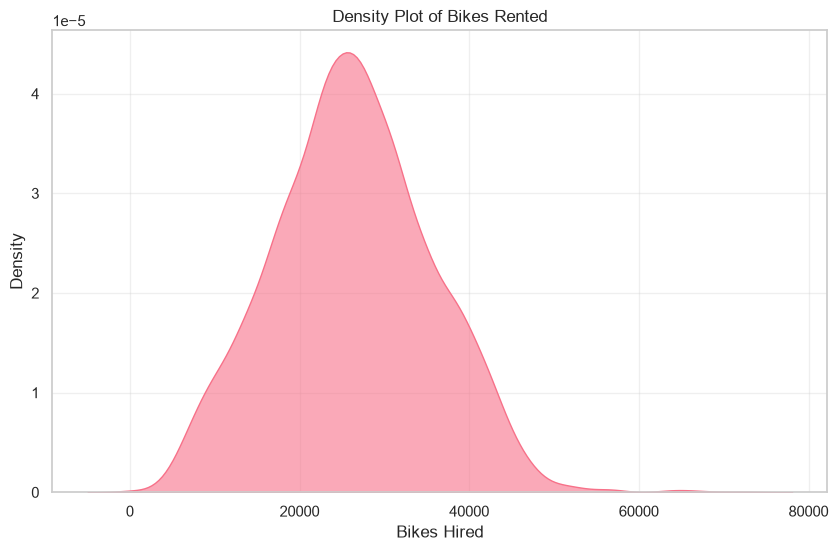

In [35]:
# Overall density
plt.figure(figsize=(10, 6))
sns.kdeplot(data=bike, x='bikes_hired', fill=True, alpha=0.6)
plt.title('Density Plot of Bikes Rented')
plt.xlabel('Bikes Hired')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

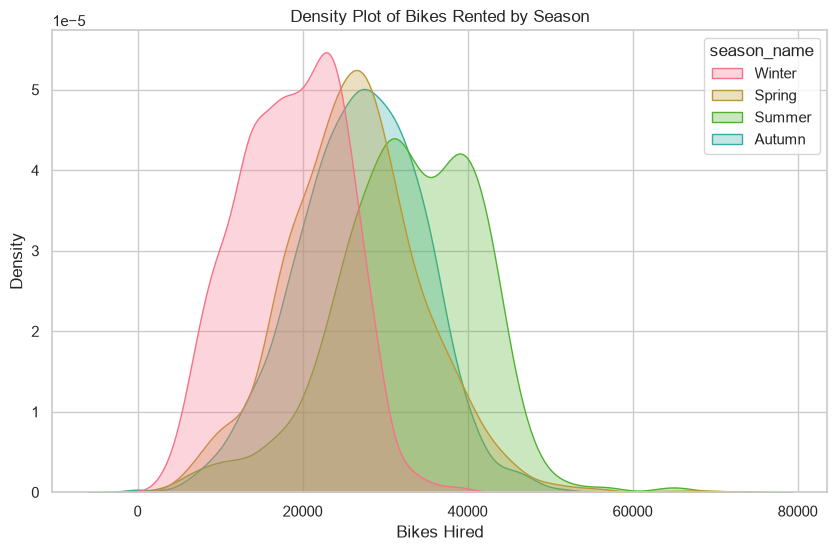

In [36]:
# Density by season, all on one axis.
# common_norm=False -> each season's curve integrates to 1 on its own.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=bike, x='bikes_hired', hue='season_name',
            fill=True, alpha=0.3, common_norm=False)
plt.title('Density Plot of Bikes Rented by Season')
plt.xlabel('Bikes Hired')
plt.ylabel('Density')
plt.show()

In [ ]:
# One density panel per season (independent scales)
g = sns.FacetGrid(bike, col='season_name', col_wrap=2, sharex=False, sharey=False)
g.map(sns.kdeplot, 'bikes_hired', fill=True, alpha=0.6)
g.set_titles("{col_name}")
g.set_axis_labels('Bikes Hired', 'Density')
plt.tight_layout()
plt.show()

In [ ]:
# One density panel per month, in calendar order
g = sns.FacetGrid(
    bike, col='month_name', col_wrap=3,
    col_order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    sharex=False, sharey=False
)
g.map(sns.kdeplot, 'bikes_hired', fill=True, alpha=0.6)
g.set_titles("{col_name}")
g.set_axis_labels('Bikes Hired', 'Density')
plt.tight_layout()
plt.show()

## 8. Boxplots & violin plots

Compare the spread and central tendency of hires across days, months, and seasons.
Boxplots show median, quartiles, and outliers; violin plots add the distribution shape.

### 8.1 By day of week

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=bike, x='day_of_week', y='bikes_hired')
plt.title('Boxplot of Bikes Hired by Day of the Week')
plt.xlabel('Day of week')
plt.ylabel('Bikes Hired')
plt.grid(True, alpha=0.3)
plt.show()

### 8.2 By month

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=bike, x='month_name', y='bikes_hired')
plt.title('Boxplot of Bikes Hired by Month')
plt.xlabel('Month')
plt.ylabel('Bikes Hired')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### 8.3 By month, coloured by season

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=bike, x='month_name', y='bikes_hired', hue='season_name')
plt.title('Boxplot of Bikes Hired by Month and Season')
plt.xlabel('Month')
plt.ylabel('Bikes Hired')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.grid(True, alpha=0.3)
plt.show()

### 8.4 Violin plot by month

The width of each "violin" shows where data is concentrated.

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=bike, x='month_name', y='bikes_hired')
plt.title('Violin Plot of Bikes Hired by Month')
plt.xlabel('Month')
plt.ylabel('Bikes Hired')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## 9. Weather correlations

Do temperature, humidity, and pressure relate to how many bikes are hired?
`regplot` / `lmplot` add fitted regression lines to reveal the trend.

### 9.1 Temperature

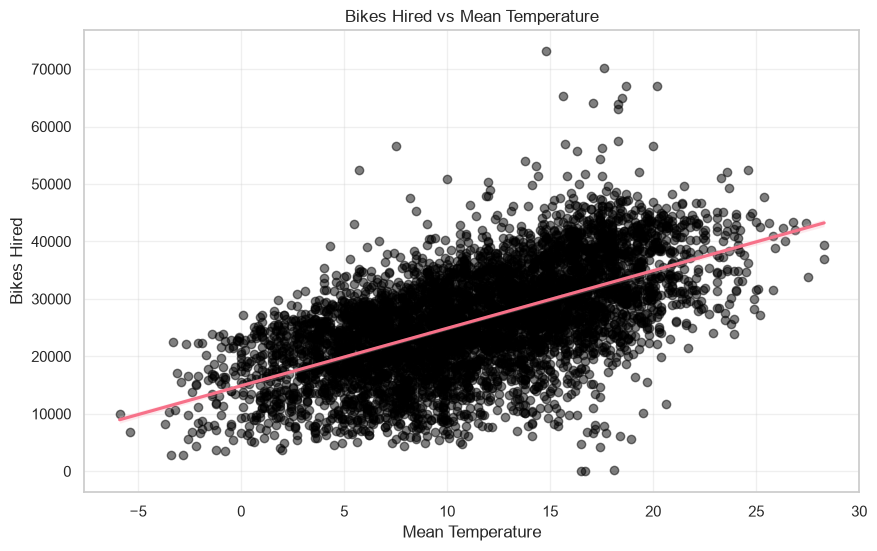

In [37]:
plt.figure(figsize=(10, 6))
sns.regplot(data=bike, x='temp', y='bikes_hired',
            scatter_kws={'alpha': 0.5, 'color': 'black'})
plt.title('Bikes Hired vs Mean Temperature')
plt.xlabel('Mean Temperature')
plt.ylabel('Bikes Hired')
plt.grid(True, alpha=0.3)
plt.show()

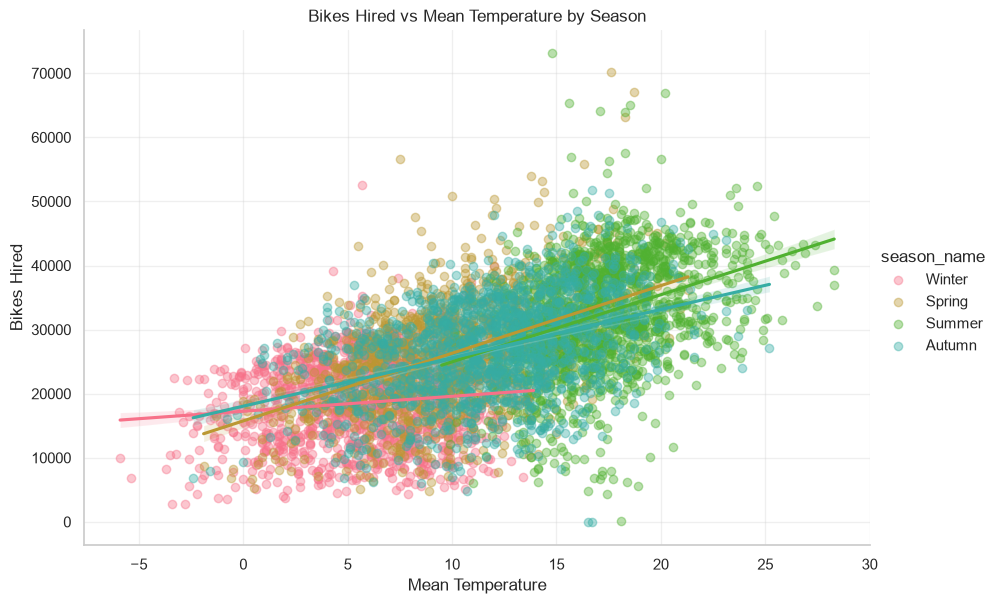

In [39]:
# One regression line per season, overlaid
sns.lmplot(data=bike, x='temp', y='bikes_hired', hue='season_name',
           scatter_kws={'alpha': 0.4}, height=6, aspect=1.5)
plt.title('Bikes Hired vs Mean Temperature by Season')
plt.xlabel('Mean Temperature')
plt.ylabel('Bikes Hired')
plt.grid(True, alpha=0.3)
plt.show()

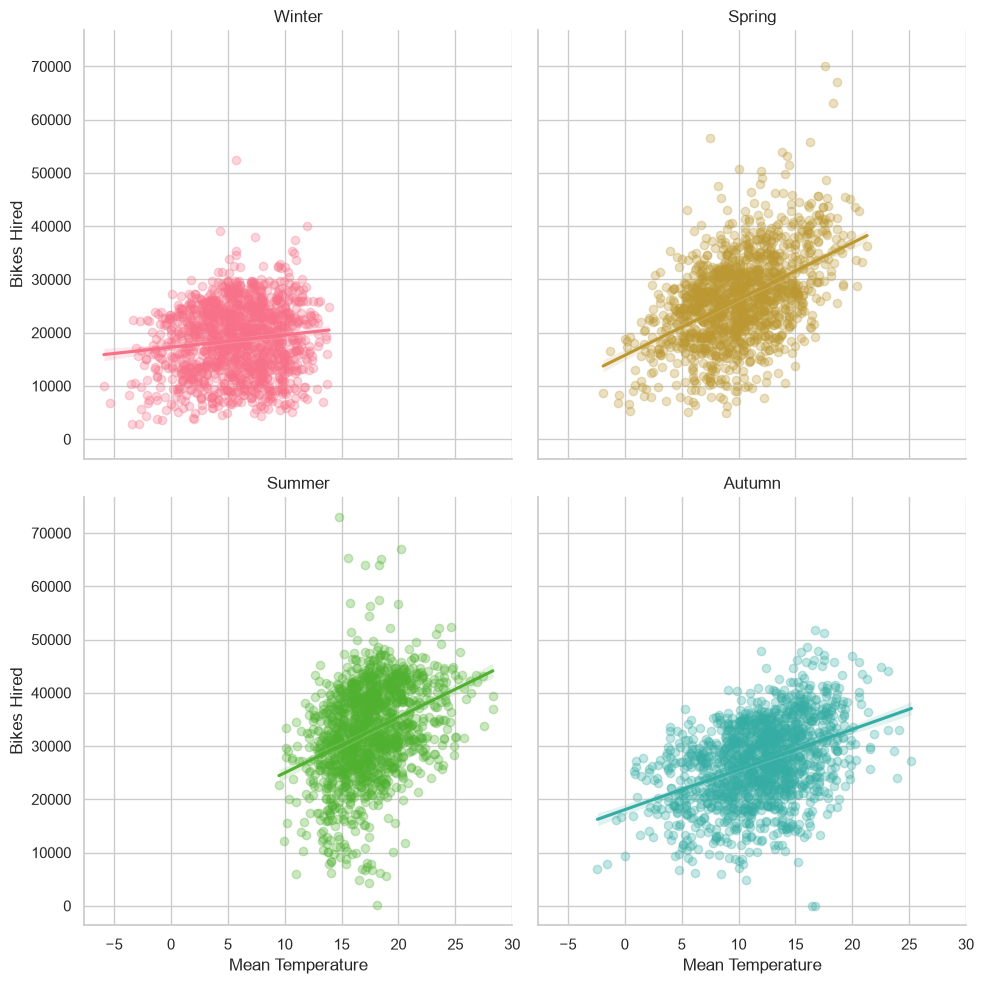

In [41]:
# One panel per season
g = sns.lmplot(data=bike, x='temp', y='bikes_hired',hue='season_name',
               col='season_name', col_wrap=2,
               height=5, aspect=1, scatter_kws={'alpha': 0.3})
g.set_axis_labels('Mean Temperature', 'Bikes Hired')
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### 9.2 Humidity

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=bike, x='humidity', y='bikes_hired',
            scatter_kws={'alpha': 0.5, 'color': 'black'})
plt.title('Bikes Hired vs Humidity')
plt.xlabel('Humidity')
plt.ylabel('Bikes Hired')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
sns.lmplot(data=bike, x='humidity', y='bikes_hired', hue='season_name',
           scatter_kws={'alpha': 0.4}, height=6, aspect=1.5)
plt.title('Bikes Hired vs Humidity by Season')
plt.xlabel('Humidity')
plt.ylabel('Bikes Hired')
plt.grid(True, alpha=0.3)
plt.show()

### 9.3 Pressure

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=bike, x='pressure', y='bikes_hired', scatter_kws={'alpha': 0.5})
plt.title('Bikes Hired vs Pressure')
plt.xlabel('Pressure')
plt.ylabel('Bikes Hired')
plt.grid(True, alpha=0.3)
plt.show()